In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# --- styling ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# --- connection ---
DB_PATH = "../db/fpl.db"
con = sqlite3.connect(DB_PATH)

print("Connected.")

Matplotlib is building the font cache; this may take a moment.


Connected.


## Section 1: Season Overview

Four seasons loaded: 2022-23 through 2025-26. The 2022-23 season contains 37 gameweeks. 
The 2025-26 season is ongoing (GW31 at time of writing).

In [2]:
# ── Section 1: Season Overview ──────────────────────────────────────────────

df_seasons = pd.read_sql("""
    SELECT 
        season,
        COUNT(*) AS rows,
        COUNT(DISTINCT player_id) AS players,
        COUNT(DISTINCT gameweek_id) AS gameweeks
    FROM player_gameweek_stats
    GROUP BY season
    ORDER BY season
""", con)

print(df_seasons.to_string(index=False))

 season  rows  players  gameweeks
2022-23 24957      778         37
2023-24 28445      824         38
2024-25 27231      804         38
2025-26 23750      825         31


## Section 2: 2025-26 Season — Player Overview by Position

All figures below are from the `players` table, which stores current-season 
(2025-26) values only.

Defenders lead on average points. This is due to a combination of higher clean sheet freqeuency compared to the 2024/2025 season, as well as the introduction of the defensive contribution points 
system, which rewards tackles, blocks, and interceptions.


In [3]:
df_players = pd.read_sql("""
    SELECT 
        pos.singular_name                        AS position,
        COUNT(*)                                 AS players,
        ROUND(AVG(p.total_points), 1)            AS avg_points,
        ROUND(AVG(p.now_cost) / 10.0, 1)        AS avg_price_m,
        MAX(p.total_points)                      AS max_points
    FROM players p
    JOIN positions pos ON p.position_id = pos.id
    GROUP BY pos.singular_name
    ORDER BY avg_points DESC
""", con)

print(df_players.to_string(index=False))

  position  players  avg_points  avg_price_m  max_points
  Defender      268        36.8          4.4         173
   Forward       92        36.0          5.6         197
Midfielder      370        34.5          5.2         189
Goalkeeper       95        22.0          4.2         129


C:\Users\Alban\AppData\Local\Temp\ipykernel_14024\581878161.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_players, x="position", y="avg_points", ax=axes[0], palette="muted")
C:\Users\Alban\AppData\Local\Temp\ipykernel_14024\581878161.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_players, x="position", y="avg_price_m", ax=axes[1], palette="muted")


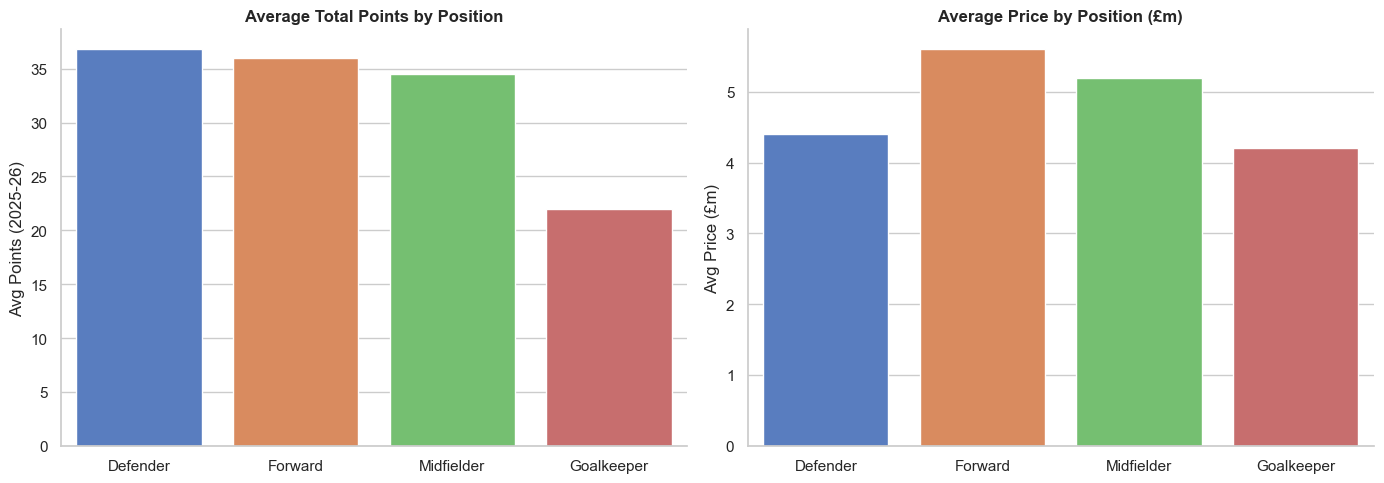

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- average points by position ---
sns.barplot(data=df_players, x="position", y="avg_points", ax=axes[0], palette="muted")
axes[0].set_title("Average Total Points by Position", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Avg Points (2025-26)")

# --- average price by position ---
sns.barplot(data=df_players, x="position", y="avg_price_m", ax=axes[1], palette="muted")
axes[1].set_title("Average Price by Position (£m)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Price (£m)")

plt.tight_layout()
plt.show()


## Section 3: Player Value Analysis

Points per million spent: identifying players who outperform their price bracket. Constraint - 900 minutes or roughly 10 games worth of game time.

Price is as of GW31

In [5]:
df_value = pd.read_sql("""
    SELECT 
        p.web_name,
        pos.singular_name                           AS position,
        t.name                                      AS team,
        p.now_cost / 10.0                           AS price_m,
        p.total_points,
        ROUND(p.total_points / (p.now_cost / 10.0), 1) AS points_per_million
    FROM players p
    JOIN positions pos ON p.position_id = pos.id
    JOIN teams t ON p.team_id = t.id
    WHERE p.minutes >= 900
    ORDER BY points_per_million DESC
    LIMIT 20
""", con)

print(df_value.to_string(index=False))


  web_name   position           team  price_m  total_points  points_per_million
    Senesi   Defender    Bournemouth      5.1           137                26.9
 Van Hecke   Defender       Brighton      4.5           120                26.7
     Guéhi   Defender       Man City      5.1           135                26.5
    Garner Midfielder        Everton      5.3           139                26.2
  Truffert   Defender    Bournemouth      4.7           122                26.0
  Richards   Defender Crystal Palace      4.4           114                25.9
     Keane   Defender        Everton      4.6           118                25.7
   Mukiele   Defender     Sunderland      4.5           115                25.6
     Rodon   Defender          Leeds      3.9            99                25.4
     Stach Midfielder          Leeds      4.8           122                25.4
   Lacroix   Defender Crystal Palace      5.1           128                25.1
  Anderson Midfielder  Nott'm Forest    

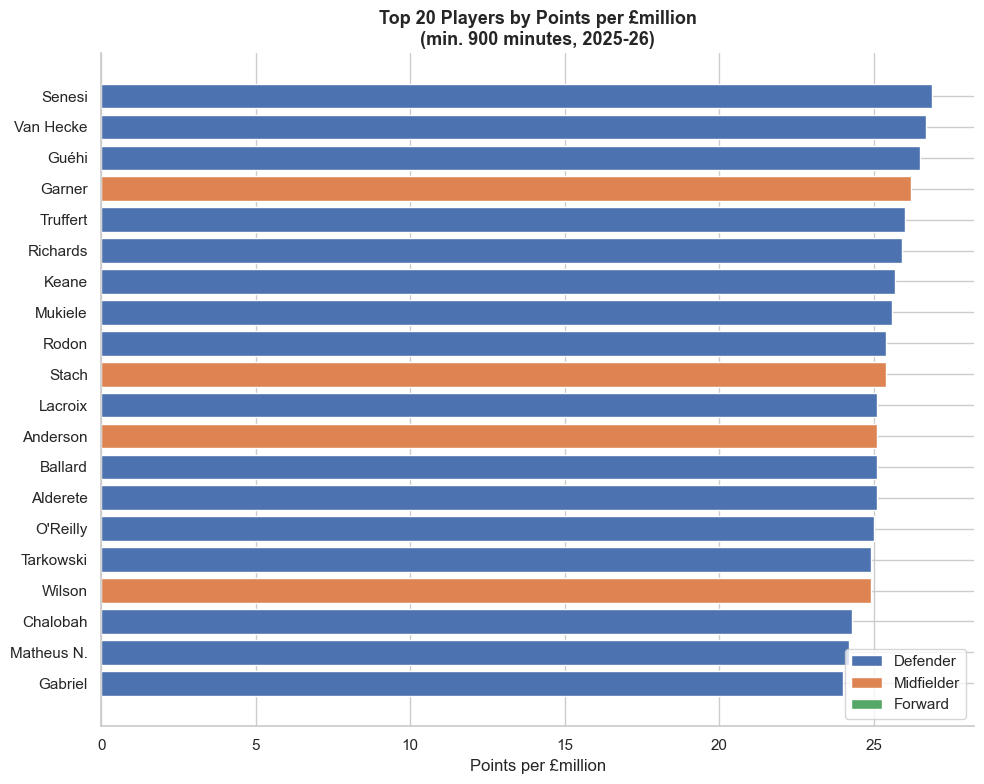

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = df_value["position"].map({
    "Defender": "#4C72B0",
    "Midfielder": "#DD8452",
    "Forward": "#55A868",
    "Goalkeeper": "#C44E52"
})

bars = ax.barh(df_value["web_name"], df_value["points_per_million"], color=colors)

ax.set_xlabel("Points per £million", fontsize=12)
ax.set_title("Top 20 Players by Points per £million\n(min. 900 minutes, 2025-26)", 
             fontweight="bold", fontsize=13)
ax.invert_yaxis()

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4C72B0", label="Defender"),
    Patch(facecolor="#DD8452", label="Midfielder"),
    Patch(facecolor="#55A868", label="Forward"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

## Section 4: Premium Players - Are they really worth it?

While cheaper players seem to be punching well above their weight, are premiums still worth it this season?

In [7]:
df_premium = pd.read_sql("""
    SELECT 
        p.web_name,
        t.name                                          AS team,
        pos.singular_name                               AS position,
        p.now_cost / 10.0                               AS price,
        p.total_points,
        ROUND(p.total_points / (p.now_cost / 10.0), 1) AS points_per_million,
        ROUND(p.expected_goals, 1)                      AS xG,
        ROUND(p.expected_assists, 1)                    AS xA
    FROM players p
    JOIN teams t ON p.team_id = t.id
    JOIN positions pos ON p.position_id = pos.id
    WHERE p.now_cost >= 80
      AND p.minutes >= 900
    ORDER BY p.total_points DESC
""", con)

print(df_premium.to_string(index=False))


   web_name        team   position  price  total_points  points_per_million   xG  xA
    Haaland    Man City    Forward   14.4           197                13.7 21.1 1.9
B.Fernandes     Man Utd Midfielder   10.3           189                18.3 10.3 9.0
    Semenyo    Man City Midfielder    8.2           174                21.2  9.9 2.3
       Saka     Arsenal Midfielder    9.8           133                13.6  7.0 5.8
    Ekitiké   Liverpool    Forward    9.3           125                13.4 10.1 2.5
     Mbeumo     Man Utd Midfielder    8.6           122                14.2  8.0 4.3
      Cunha     Man Utd Midfielder    8.0           117                14.6  5.8 2.6
      Foden    Man City Midfielder    8.0           112                14.0  5.3 4.0
    Watkins Aston Villa    Forward    8.5           109                12.8 10.6 1.1
      Wirtz   Liverpool Midfielder    8.3           105                12.7  5.7 4.4
   Gyökeres     Arsenal    Forward    8.8           101          

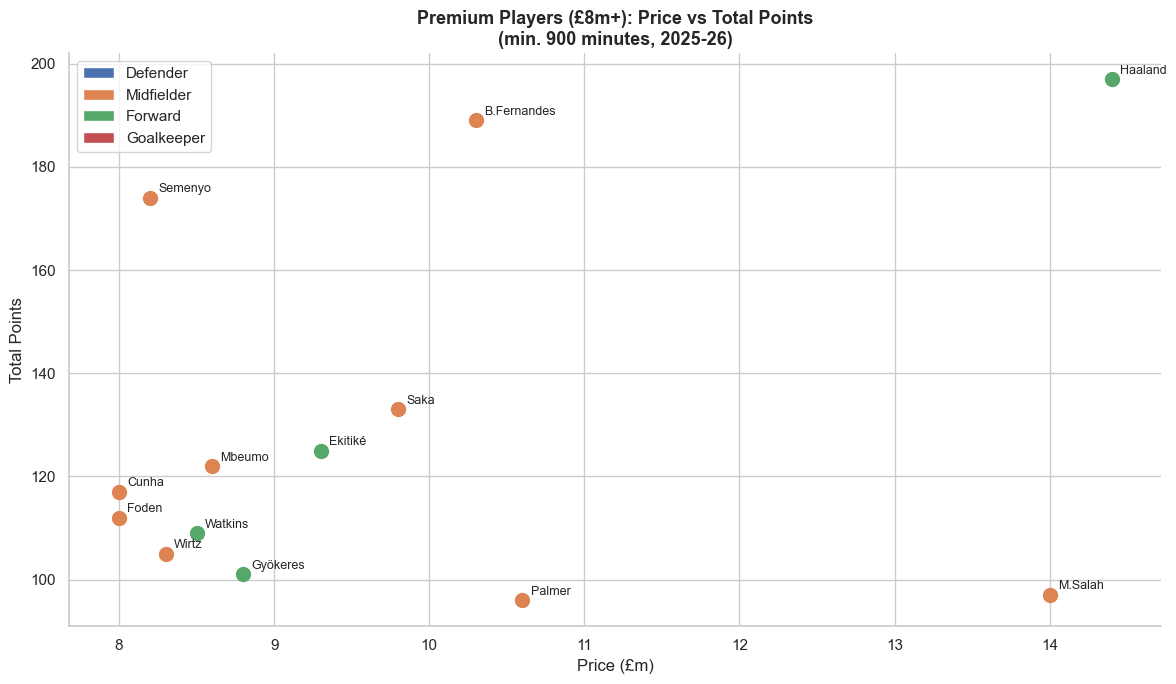

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

position_colors = {
    "Defender": "#4C72B0",
    "Midfielder": "#DD8452",
    "Forward": "#55A868",
    "Goalkeeper": "#C44E52"
}

for _, row in df_premium.iterrows():
    color = position_colors.get(row["position"], "grey")
    ax.scatter(row["price"], row["total_points"], color=color, s=100, zorder=3)
    ax.annotate(row["web_name"], (row["price"], row["total_points"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.set_xlabel("Price (£m)", fontsize=12)
ax.set_ylabel("Total Points", fontsize=12)
ax.set_title("Premium Players (£8m+): Price vs Total Points\n(min. 900 minutes, 2025-26)",
             fontweight="bold", fontsize=13)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in position_colors.items()]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

- **Salah** at 6.9 points per million - by far the worst value in the game. The King of FPL is having his worst season ever, and for the first time ever has started many games on the bench.

- **Semenyo** at £8.2m with 174 points - the clear winner, and possibly Premier League player of the Season. Must have on any team, and he has not slowed down after his mid-season transfer from Bournemouth to City.

- **B.Fernandes** leading outfield players with 189 points and 9 assists — another contender for player of teh season and a must on every team, even with United's unpredictability.

- **Haaland** - high price, guaranteed high points. The safe option.

## Section 5: Home vs Away splits across all seasons

Do players consistently score more points at home? Using all four seasons 
of gameweek data to get a robust answer.

In [9]:
df_home_away = pd.read_sql("""
    SELECT
        season,
        was_home,
        ROUND(AVG(total_points), 2)     AS avg_points,
        ROUND(AVG(goals_scored), 3)     AS avg_goals,
        ROUND(AVG(assists), 3)          AS avg_assists,
        ROUND(AVG(clean_sheets), 3)     AS avg_clean_sheets,
        COUNT(*)                        AS rows
    FROM player_gameweek_stats
    WHERE minutes > 0
    GROUP BY season, was_home
    ORDER BY season, was_home
""", con)

print(df_home_away.to_string(index=False))


 season  was_home  avg_points  avg_goals  avg_assists  avg_clean_sheets  rows
2022-23         0        2.52      0.078        0.070             0.159  5366
2022-23         1        3.07      0.105        0.093             0.248  5353
2023-24         0        2.54      0.093        0.084             0.142  5533
2023-24         1        2.97      0.116        0.104             0.197  5486
2024-25         0        2.65      0.091        0.081             0.174  5722
2024-25         1        2.73      0.094        0.087             0.181  5691
2025-26         0        2.86      0.080        0.073             0.181  4642
2025-26         1        3.14      0.093        0.090             0.220  4674


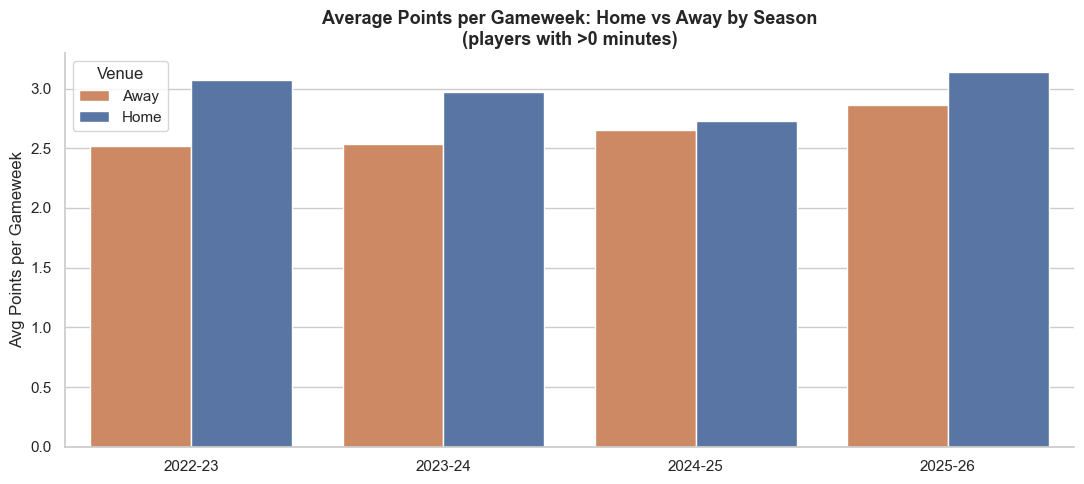

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

df_home_away["venue"] = df_home_away["was_home"].map({1: "Home", 0: "Away"})

sns.barplot(data=df_home_away, x="season", y="avg_points", 
            hue="venue", palette={"Home": "#4C72B0", "Away": "#DD8452"}, ax=ax)

ax.set_title("Average Points per Gameweek: Home vs Away by Season\n(players with >0 minutes)", 
             fontweight="bold", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Avg Points per Gameweek")
ax.legend(title="Venue")

plt.tight_layout()
plt.show()

While home advantage is consitent across seasons, the 2024-2025 is the anomaly, with the smallest gap. Away teams performed unusually well.

## Section 6: Player Consistency

We can look at the standard deviation of gameweek points by measuring the haul rate. A haul is defined as 9+ points.

In [12]:
df_consistency = pd.read_sql("""
    SELECT
        p.web_name,
        t.name                                          AS team,
        pos.singular_name                               AS position,
        COUNT(*)                                        AS gameweeks,
        ROUND(AVG(pgs.total_points), 2)                AS avg_points,
        ROUND(AVG(pgs.total_points) * COUNT(*), 0)     AS est_total,
        ROUND(SUM(CASE WHEN pgs.total_points >= 9 
                  THEN 1 ELSE 0 END) * 1.0 
              / COUNT(*), 3)                            AS haul_rate
    FROM player_gameweek_stats pgs
    JOIN players p ON pgs.player_id = p.id
    JOIN teams t ON p.team_id = t.id
    JOIN positions pos ON p.position_id = pos.id
    WHERE pgs.season = '2025-26'
      AND pgs.minutes > 0
    GROUP BY pgs.player_id
    HAVING COUNT(*) >= 20
    ORDER BY haul_rate DESC
    LIMIT 15
""", con)

print(df_consistency.to_string(index=False))

     web_name           team   position  gameweeks  avg_points  est_total  haul_rate
      Gabriel        Arsenal   Defender         24        7.08      170.0      0.458
  B.Fernandes        Man Utd Midfielder         28        6.75      189.0      0.393
      Haaland       Man City    Forward         29        6.79      197.0      0.379
     Bruno G.      Newcastle Midfielder         23        5.83      134.0      0.348
       Wilson         Fulham Midfielder         29        5.24      152.0      0.276
Dewsbury-Hall        Everton Midfielder         24        4.88      117.0      0.250
     Grealish        Everton Midfielder         20        3.95       79.0      0.250
      Ekitiké      Liverpool    Forward         28        4.46      125.0      0.250
        Muñoz Crystal Palace   Defender         21        5.19      109.0      0.238
      Ballard     Sunderland   Defender         26        4.54      118.0      0.231
   João Pedro        Chelsea    Forward         31        5.29   

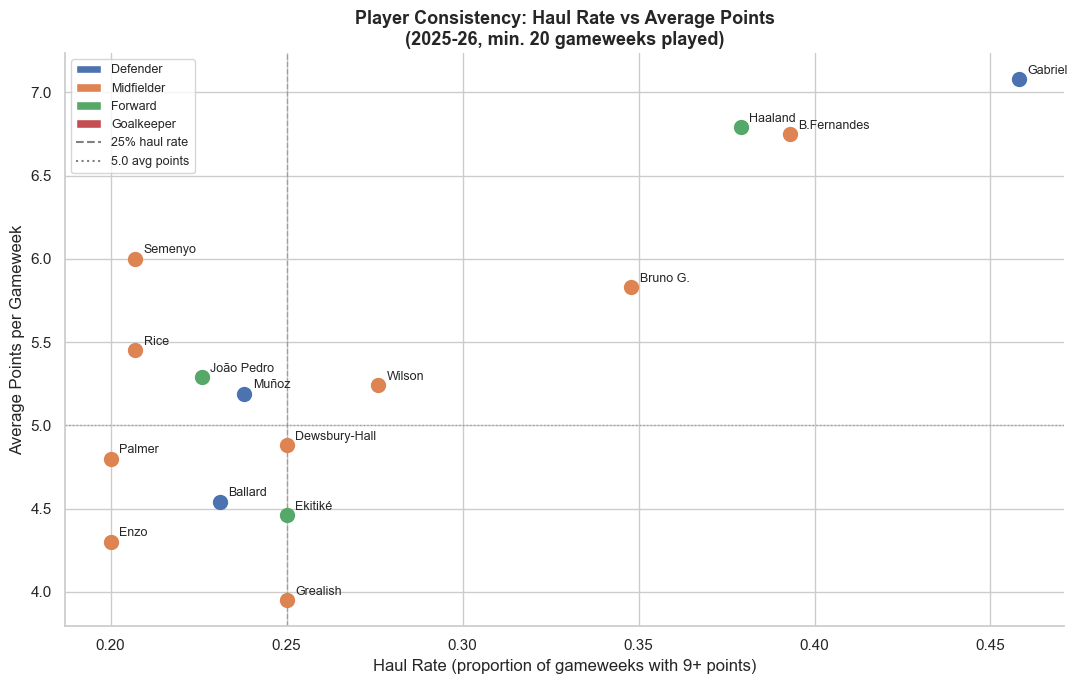

In [13]:
fig, ax = plt.subplots(figsize=(11, 7))

position_colors = {
    "Defender": "#4C72B0",
    "Midfielder": "#DD8452",
    "Forward": "#55A868",
    "Goalkeeper": "#C44E52"
}

for _, row in df_consistency.iterrows():
    color = position_colors.get(row["position"], "grey")
    ax.scatter(row["haul_rate"], row["avg_points"], color=color, s=100, zorder=3)
    ax.annotate(row["web_name"], (row["haul_rate"], row["avg_points"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

ax.axvline(x=0.25, color="grey", linestyle="--", linewidth=1, alpha=0.6, label="25% haul rate")
ax.axhline(y=5.0, color="grey", linestyle=":", linewidth=1, alpha=0.6, label="5.0 avg points")

ax.set_xlabel("Haul Rate (proportion of gameweeks with 9+ points)", fontsize=12)
ax.set_ylabel("Average Points per Gameweek", fontsize=12)
ax.set_title("Player Consistency: Haul Rate vs Average Points\n(2025-26, min. 20 gameweeks played)",
             fontweight="bold", fontsize=13)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in position_colors.items()]
legend_elements.append(plt.Line2D([0], [0], color="grey", linestyle="--", label="25% haul rate"))
legend_elements.append(plt.Line2D([0], [0], color="grey", linestyle=":", label="5.0 avg points"))
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.show()

- **Top Right**: Gabriel is the clear winner, with high haul rate and average. Haaland and Fernandes aren't too far behind.
- **Center**: Bruno Guimaraes - an intersting option for a while, although injured as of GW31.
- **Top Left**: Semenyo, Rice not too far behind. Less outright hauls but consistent points.


In [14]:
# ── Close connection ─────────────────────────────────────────────────────────
con.close()
print("Connection closed.")

Connection closed.


## Summary

Key findings from the 2025-26 season EDA:

- **Defensive contribution points** have definitely changed the game and overall FPL strategy. Defenders now domiante in value, suggesting a shift to a back four
- **Semenyo** is the standout value pick: 174 points at £8.2m, 
  outperforming players costing twice as much
- **Gabriel** leads all players on haul rate (0.46) 
- **Salah** had a significantly below-par season by his standards - should not be in any competitive team.
- **Home advantage** is consistent across all seasons but nearly disappeared 
  in 2024-25, it's back this season although not as pronounced as in the past
